# 02 — Kalshi Market Data Exploration

Characterizes the Kalshi earnings-mention dataset used throughout the project.
All figures are saved to `outputs/results/figures/` for inclusion in the final report.

**Dataset:** 93 companies, ~1,090 settled binary markets, Jan–Apr 2026 (Q4 2025 / Q1 2026 earnings season).

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, '..')
from src.constants import RESULTS_DIR

FIGURES_DIR = RESULTS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RAW_KALSHI = Path('../data/raw/kalshi')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

In [2]:

# Load all settled markets into a flat DataFrame
rows = []
for f in sorted(RAW_KALSHI.glob('KXEARNINGS*.json')):
    markets = json.loads(f.read_text(encoding='utf-8'))
    for m in markets:
        series = f.stem.split('-')[0]
        raw_prob = m.get('previous_price_dollars')
        rows.append({
            'series':       series,
            'ticker':       m.get('ticker', ''),
            'word':         (m.get('custom_strike') or {}).get('Word', ''),
            'result':       m.get('result', ''),
            'implied_prob': float(raw_prob) if raw_prob is not None else None,
            'close_time':   pd.to_datetime(m.get('close_time', '')[:10]),
            'status':       m.get('status', ''),
        })

df = pd.DataFrame(rows)
df['label'] = (df['result'] == 'yes').astype(int)

def ticker_label(series: str) -> str:
    """Strip KXEARNINGSM ENTION prefix to get a readable company label."""
    if 'MENTION' in series:
        return series.split('MENTION')[-1]
    return series

print(f"Total markets:    {len(df)}")
print(f"Companies:        {df['series'].nunique()}")
print(f"Unique words:     {df['word'].nunique()}")
print(f"Date range:       {df['close_time'].min().date()} to {df['close_time'].max().date()}")
print(f"Overall yes rate: {df['label'].mean():.1%}")
df.head()


Total markets:    1009
Companies:        86
Unique words:     653
Date range:       2026-01-15 to 2026-04-09
Overall yes rate: 57.7%


,series,ticker,word,result,implied_prob,close_time,status,label
0,KXEARNINGSMENTIONAAL,KXEARNINGSMENTIONAAL-26JUN30-WORL,World Cup,no,0.01,2026-01-27,finalized,0
1,KXEARNINGSMENTIONAAL,KXEARNINGSMENTIONAAL-26JUN30-WEAT,Weather,yes,0.99,2026-01-27,finalized,1
2,KXEARNINGSMENTIONAAL,KXEARNINGSMENTIONAAL-26JUN30-TARI,Tariff,no,0.01,2026-01-27,finalized,0
3,KXEARNINGSMENTIONAAL,KXEARNINGSMENTIONAAL-26JUN30-SHUT,Shutdown / Shut Down,yes,0.99,2026-01-27,finalized,1
4,KXEARNINGSMENTIONAAL,KXEARNINGSMENTIONAAL-26JUN30-RECO,Record,yes,0.99,2026-01-27,finalized,1


## 1. Markets per company

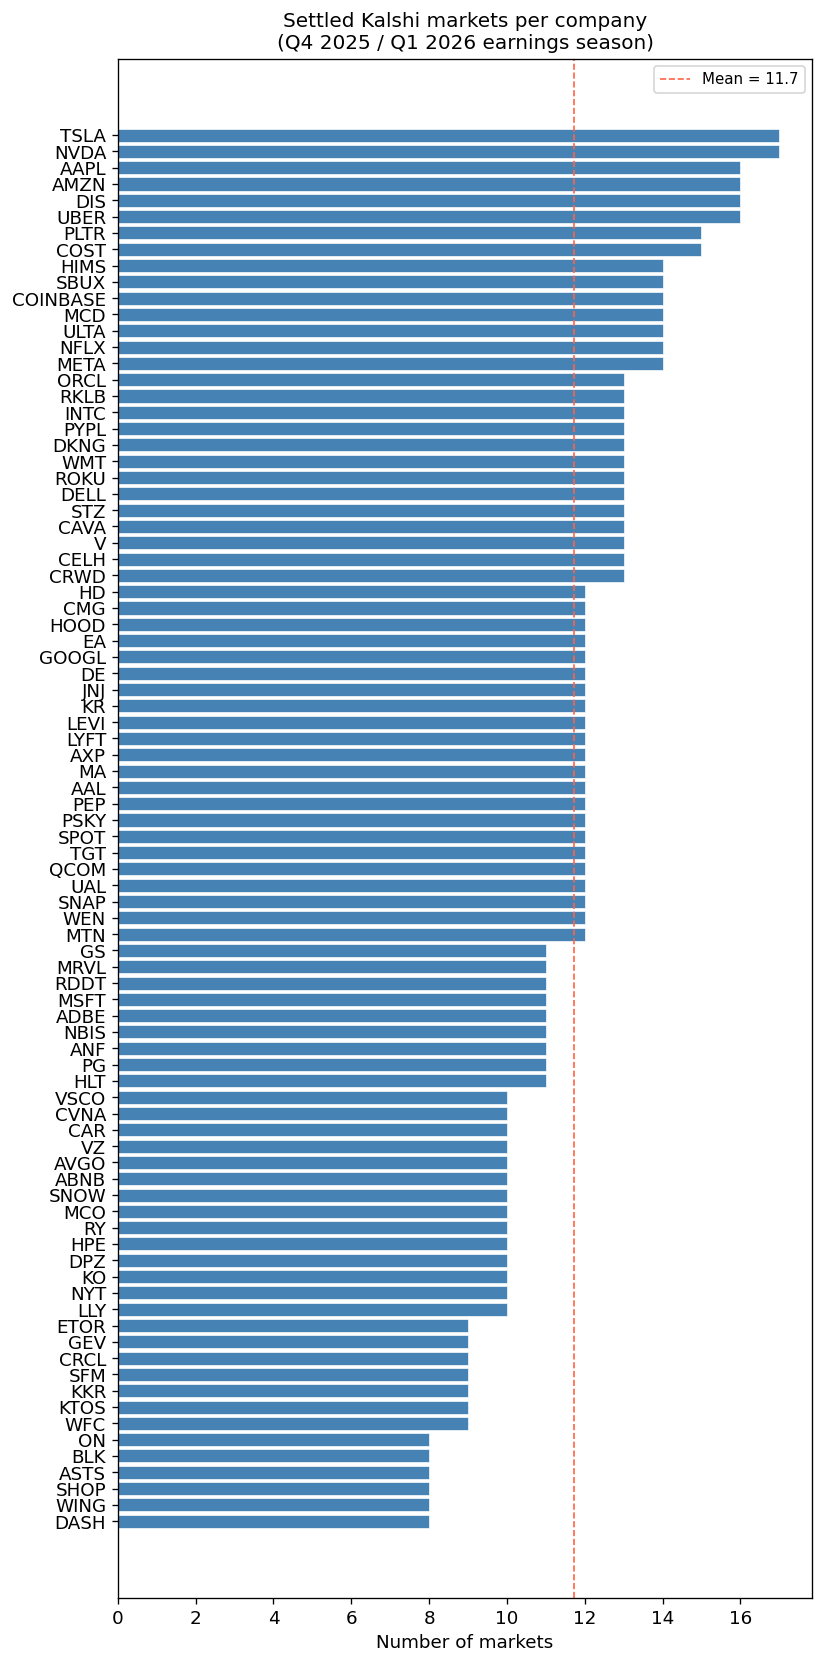

In [3]:
counts = df.groupby('series').size().sort_values(ascending=True)
labels = [ticker_label(s) for s in counts.index]

fig, ax = plt.subplots(figsize=(7, 14))
ax.barh(labels, counts.values, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(counts.values.mean(), color='tomato', linestyle='--', linewidth=1,
           label=f'Mean = {counts.values.mean():.1f}')
ax.set_xlabel('Number of markets')
ax.set_title('Settled Kalshi markets per company\n(Q4 2025 / Q1 2026 earnings season)', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'kalshi_markets_per_company.png', bbox_inches='tight')
plt.show()

## 2. Earnings call date distribution

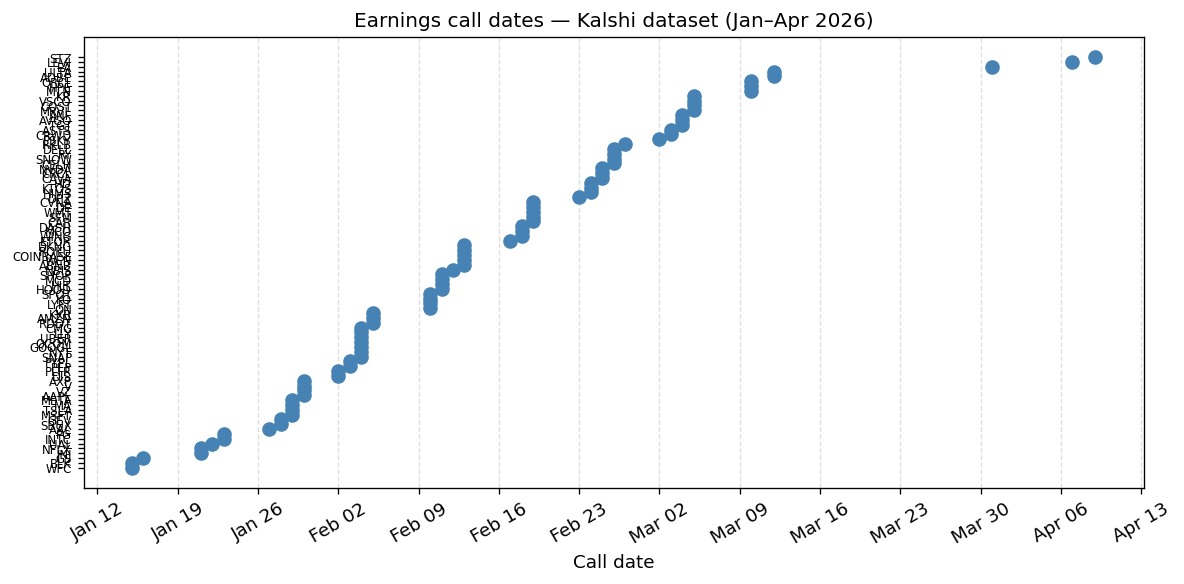

In [4]:
call_dates = (
    df.drop_duplicates('series')[['series', 'close_time']]
    .sort_values('close_time')
    .reset_index(drop=True)
)
call_dates['label'] = call_dates['series'].apply(ticker_label)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(call_dates['close_time'], range(len(call_dates)), s=60, color='steelblue', zorder=3)
ax.set_yticks(range(len(call_dates)))
ax.set_yticklabels(call_dates['label'].tolist(), fontsize=7)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.xticks(rotation=30)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_title('Earnings call dates — Kalshi dataset (Jan–Apr 2026)', fontsize=12)
ax.set_xlabel('Call date')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'kalshi_call_dates.png', bbox_inches='tight')
plt.show()

## 3. Cross-company word frequency

Which words appear as prediction targets across the most companies?  
High-frequency words (e.g. "Tariff", "AI") reflect macro themes dominating the earnings season.

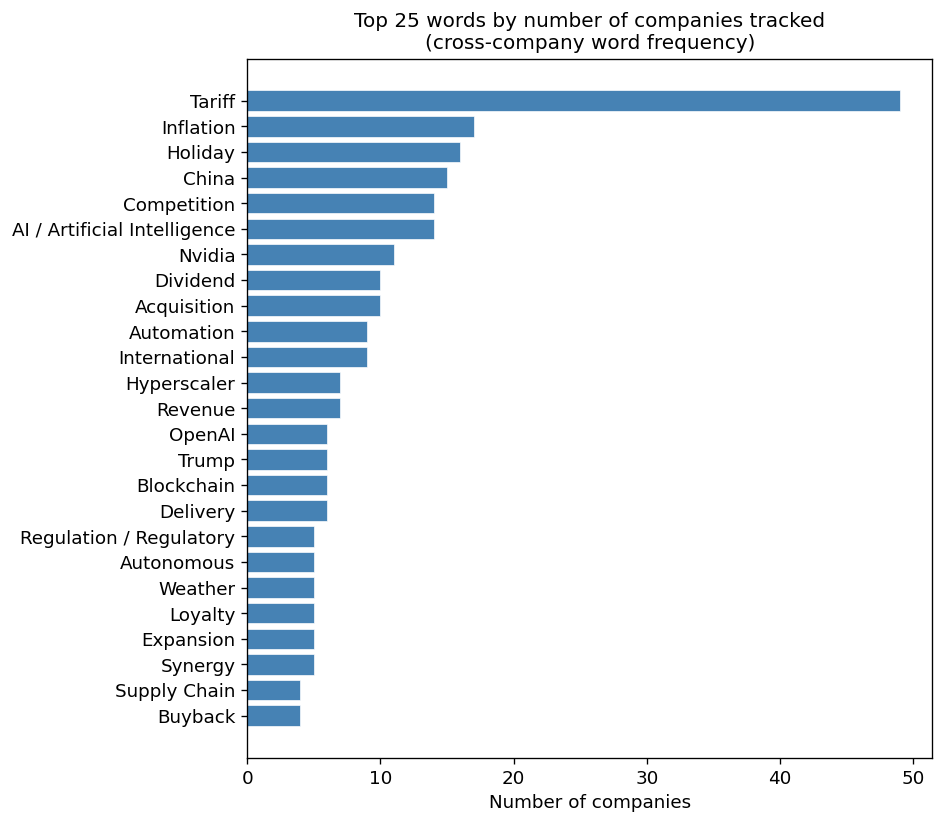

Top 15 words across companies:
  Tariff                                   49 companies  yes rate=49%
  Inflation                                17 companies  yes rate=65%
  Holiday                                  16 companies  yes rate=56%
  China                                    15 companies  yes rate=53%
  Competition                              14 companies  yes rate=71%
  AI / Artificial Intelligence             14 companies  yes rate=79%
  Nvidia                                   11 companies  yes rate=36%
  Dividend                                 10 companies  yes rate=80%
  Acquisition                              10 companies  yes rate=60%
  Automation                                9 companies  yes rate=33%
  International                             9 companies  yes rate=67%
  Hyperscaler                               7 companies  yes rate=86%
  Revenue                                   7 companies  yes rate=71%
  OpenAI                                    6 companies  ye

In [5]:
word_company_counts = (
    df.groupby('word')['series']
    .nunique()
    .sort_values(ascending=False)
    .head(25)
)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(
    word_company_counts.index[::-1],
    word_company_counts.values[::-1],
    color='steelblue', edgecolor='white', linewidth=0.4
)
ax.set_xlabel('Number of companies')
ax.set_title('Top 25 words by number of companies tracked\n(cross-company word frequency)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'kalshi_word_frequency.png', bbox_inches='tight')
plt.show()

print("Top 15 words across companies:")
for word, n in word_company_counts.head(15).items():
    rate = df[df['word'] == word]['label'].mean()
    print(f"  {word:<40s} {n:2d} companies  yes rate={rate:.0%}")

## 4. Outcome distribution (yes/no rates)

Class balance is important for classifier design. A high yes rate on specific words
means the Kalshi market may be mis-pricing them — or they are genuinely predictable.

Overall — yes: 582  no: 427  yes-rate: 57.7%


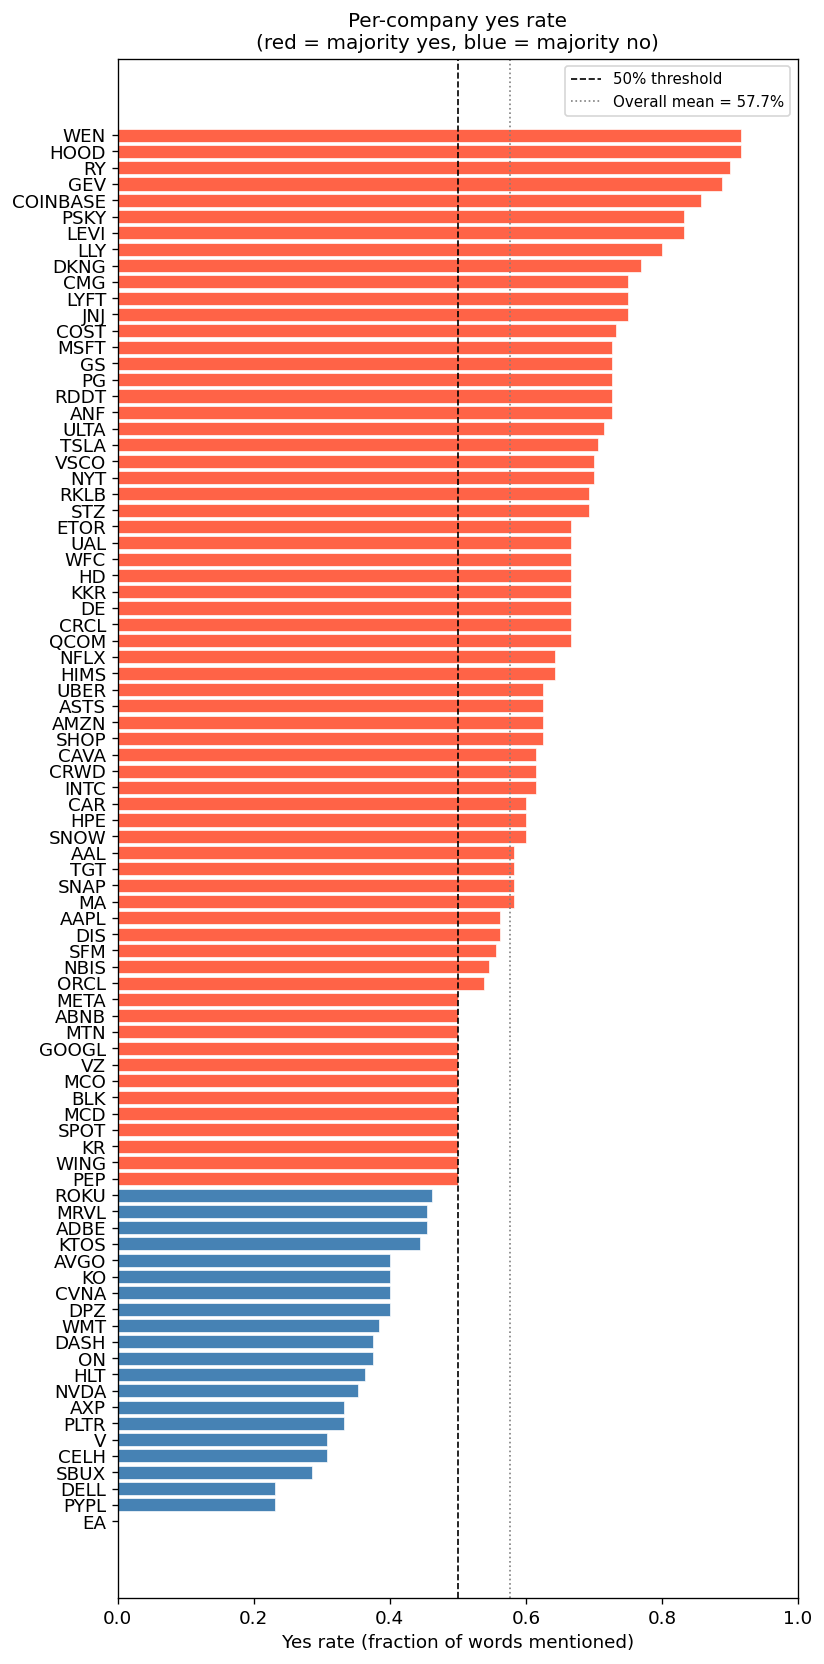

In [6]:
overall = df['result'].value_counts()
print(f"Overall — yes: {overall.get('yes', 0)}  no: {overall.get('no', 0)}  yes-rate: {df['label'].mean():.1%}")

yes_rates = (
    df.groupby('series')['label']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'yes_rate', 'count': 'n'})
    .sort_values('yes_rate', ascending=True)
)
yes_rates['label'] = [ticker_label(s) for s in yes_rates.index]

fig, ax = plt.subplots(figsize=(7, 14))
colors = ['tomato' if r >= 0.5 else 'steelblue' for r in yes_rates['yes_rate']]
ax.barh(yes_rates['label'], yes_rates['yes_rate'], color=colors, edgecolor='white', linewidth=0.4)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1, label='50% threshold')
ax.axvline(df['label'].mean(), color='gray', linestyle=':', linewidth=1,
           label=f"Overall mean = {df['label'].mean():.1%}")
ax.set_xlabel('Yes rate (fraction of words mentioned)')
ax.set_title('Per-company yes rate\n(red = majority yes, blue = majority no)', fontsize=12)
ax.set_xlim(0, 1)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'kalshi_yes_rates.png', bbox_inches='tight')
plt.show()

## 5. Kalshi implied probability calibration

**Key question:** are Kalshi prices well-calibrated?  
If markets are calibrated, the implied probability is already a near-optimal predictor —
the Brier score sets our baseline ceiling.

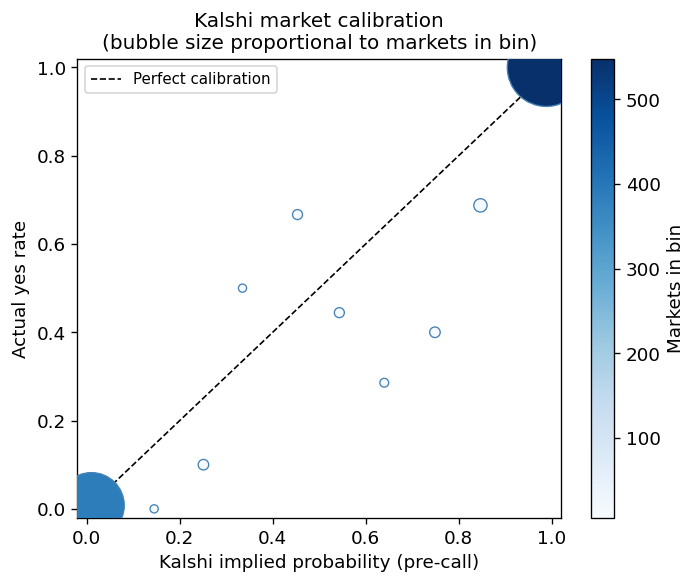

Kalshi Brier score:  0.0200
Random baseline:     0.2500
Improvement vs random: 92.0%


In [7]:
cal = df.dropna(subset=['implied_prob']).copy()
cal['prob_bin'] = pd.cut(cal['implied_prob'], bins=10, labels=False)
calib = (
    cal.groupby('prob_bin')
    .agg(mean_prob=('implied_prob', 'mean'), actual_rate=('label', 'mean'), n=('label', 'count'))
    .dropna()
)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
sc = ax.scatter(
    calib['mean_prob'], calib['actual_rate'],
    s=calib['n'] * 4, c=calib['n'], cmap='Blues',
    edgecolors='steelblue', linewidths=0.8, zorder=3
)
plt.colorbar(sc, ax=ax, label='Markets in bin')
ax.set_xlabel('Kalshi implied probability (pre-call)')
ax.set_ylabel('Actual yes rate')
ax.set_title('Kalshi market calibration\n(bubble size proportional to markets in bin)', fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'kalshi_calibration.png', bbox_inches='tight')
plt.show()

brier = np.mean((cal['implied_prob'] - cal['label']) ** 2)
random_brier = 0.25
print(f"Kalshi Brier score:  {brier:.4f}")
print(f"Random baseline:     {random_brier:.4f}")
print(f"Improvement vs random: {(random_brier - brier) / random_brier:.1%}")

## 6. Summary for report

In [8]:
print("=== Dataset Summary ===")
print(f"Total settled markets:      {len(df)}")
print(f"Companies (series):         {df['series'].nunique()}")
print(f"Unique target words:        {df['word'].nunique()}")
print(f"Date range:                 {df['close_time'].min().date()} to {df['close_time'].max().date()}")
print(f"Overall yes rate:           {df['label'].mean():.1%}  "
      f"({df['label'].sum()} yes / {(df['label'] == 0).sum()} no)")
print(f"Markets per company:        min={df.groupby('series').size().min()}  "
      f"max={df.groupby('series').size().max()}  "
      f"mean={df.groupby('series').size().mean():.1f}")
print()
print("Top 5 cross-company words:")
top5 = df.groupby('word')['series'].nunique().sort_values(ascending=False).head(5)
for word, n in top5.items():
    rate = df[df['word'] == word]['label'].mean()
    print(f"  '{word}': {n} companies, yes rate = {rate:.0%}")

=== Dataset Summary ===
Total settled markets:      1009
Companies (series):         86
Unique target words:        653
Date range:                 2026-01-15 to 2026-04-09
Overall yes rate:           57.7%  (582 yes / 427 no)
Markets per company:        min=8  max=17  mean=11.7

Top 5 cross-company words:
  'Tariff': 49 companies, yes rate = 49%
  'Inflation': 17 companies, yes rate = 65%
  'Holiday': 16 companies, yes rate = 56%
  'China': 15 companies, yes rate = 53%
  'Competition': 14 companies, yes rate = 71%
